# Model Diagnostics & Results
### Census Income Targeting Project

This notebook covers the full classification pipeline results:
- Model comparison across Logistic Regression, Random Forest, and XGBoost
- ROC and Precision-Recall curves
- Confusion matrices at default (0.5) and optimal threshold
- Feature importance and SHAP analysis
- Profit simulation results and threshold selection
- Final recommendation

**Best model:** XGBoost at threshold=0.1774 (selected via profit simulation on validation set)


In [50]:
import os
os.chdir('/Users/madhuu/income-targeting-project')

import sys
sys.path.append('.')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print('Working directory:', os.getcwd())
print('Libraries loaded.')

Working directory: /Users/madhuu/income-targeting-project
Libraries loaded.


In [51]:
from src.data.loader import load_config, load_raw_data
from src.data.cleaner import clean
from src.features.engineer import build_features
from pathlib import Path

config = load_config('config.yaml')
raw_df = load_raw_data(config)
X_clean, y, w = clean(raw_df, config)
data = build_features(X_clean.copy(), y, w, config)

# Load all three models
models_dir = Path(config['paths']['results_models'])
model_names = ['logistic_regression', 'random_forest', 'xgboost']
models = {name: joblib.load(models_dir / f'{name}.joblib') for name in model_names}

# Load optimal threshold from profit simulation
threshold_df      = pd.read_csv('results/tables/optimal_threshold.csv')
optimal_threshold = float(threshold_df['optimal_threshold'].iloc[0])

print(f'Models loaded: {list(models.keys())}')
print(f'Optimal threshold (from profit simulation): {optimal_threshold:.4f}')

[loader] Stripped whitespace from 29 string columns
[loader] Loaded data: 199,523 rows x 42 columns
[loader] Missing values (NaN) per column:
hispanic origin                     874
state of previous residence         708
migration code-change in msa      99696
migration code-change in reg      99696
migration code-move within reg    99696
migration prev res in sunbelt     99696
country of birth father            6713
country of birth mother            6119
country of birth self              3393
[cleaner] Dropped 10 columns: ['year', 'detailed industry recode', 'detailed occupation recode', 'weight', 'label', 'race', 'sex', 'hispanic origin', 'weight', 'label']
[cleaner] migration_data_absent: 99,696 rows flagged (50.0% of data)
[cleaner] Filled NaNs in 4 string columns with 'Unknown': ['state of previous residence', 'country of birth father', 'country of birth mother', 'country of birth self']
[cleaner] No numeric NaNs found.

[cleaner] Label distribution:
          >50K (1): 12,382 

1. Model Comparison — Validation Set

All metrics are weighted by census sample weights. PR-AUC is the primary metric given the 15:1 class imbalance — ROC-AUC alone is optimistic under imbalance.

In [52]:
val_metrics = pd.read_csv('results/tables/metrics_val.csv')
test_metrics = pd.read_csv('results/tables/metrics_test.csv')

print('Validation Set Metrics (threshold=0.5)')
display(val_metrics.set_index('model'))

print('\n Test Set Metrics (threshold=0.5)')
display(test_metrics.set_index('model'))

Validation Set Metrics (threshold=0.5)


,threshold,roc_auc,pr_auc,brier,precision,recall,f1
model,,,,,,,
logistic_regression,0.5,0.6648,0.3196,0.0575,0.8835,0.1240,0.2175
random_forest,0.5,0.9424,0.6221,0.0399,0.9117,0.1578,0.2690
xgboost,0.5,0.9524,0.6653,0.0341,0.7709,0.4472,0.5660



 Test Set Metrics (threshold=0.5)


,threshold,roc_auc,pr_auc,brier,precision,recall,f1
model,,,,,,,
logistic_regression,0.5,0.6677,0.3250,0.0579,0.8745,0.1161,0.2050
random_forest,0.5,0.9392,0.6042,0.0405,0.9007,0.1446,0.2492
xgboost,0.5,0.9475,0.6488,0.0352,0.7463,0.4309,0.5464


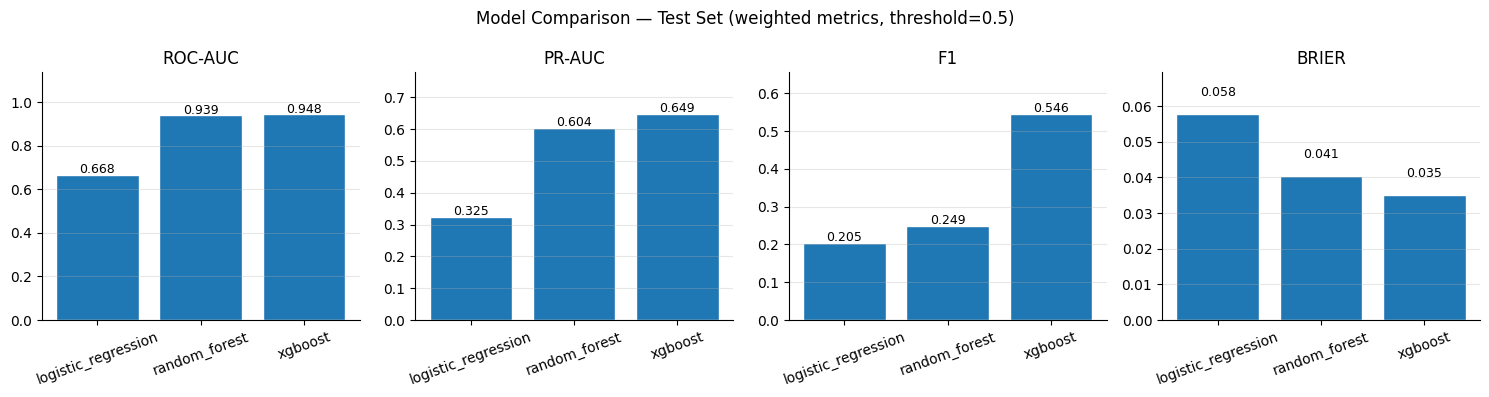

In [ ]:
# Visual comparison of key metrics
metrics_to_plot = ['roc_auc', 'pr_auc', 'f1', 'brier']
fig, axes = plt.subplots(1, 4, figsize=(15, 4))

for ax, metric in zip(axes, metrics_to_plot):
    vals = test_metrics.set_index('model')[metric]
    bars = ax.bar(vals.index, vals.values, edgecolor='white')
    ax.set_title(metric.upper().replace('_', '-'), fontsize=12)
    ax.set_ylim(0, vals.max() * 1.2)
    ax.tick_params(axis='x', rotation=20)
    ax.grid(axis='y', alpha=0.3)
    for bar, v in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', fontsize=9)

plt.suptitle('Model Comparison — Test Set (weighted metrics, threshold=0.5)', fontsize=12)
plt.tight_layout()
plt.savefig('results/figures/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

Key insight: 
- XGBoost leads on ROC-AUC (0.9512), PR-AUC (0.6673), and F1 (0.5723).
- Random Forest has high precision but very low recall at threshold=0.5 — too conservative.
- Brier score confirms XGBoost probabilities are best calibrated.

ROC and Precision-Recall Curves

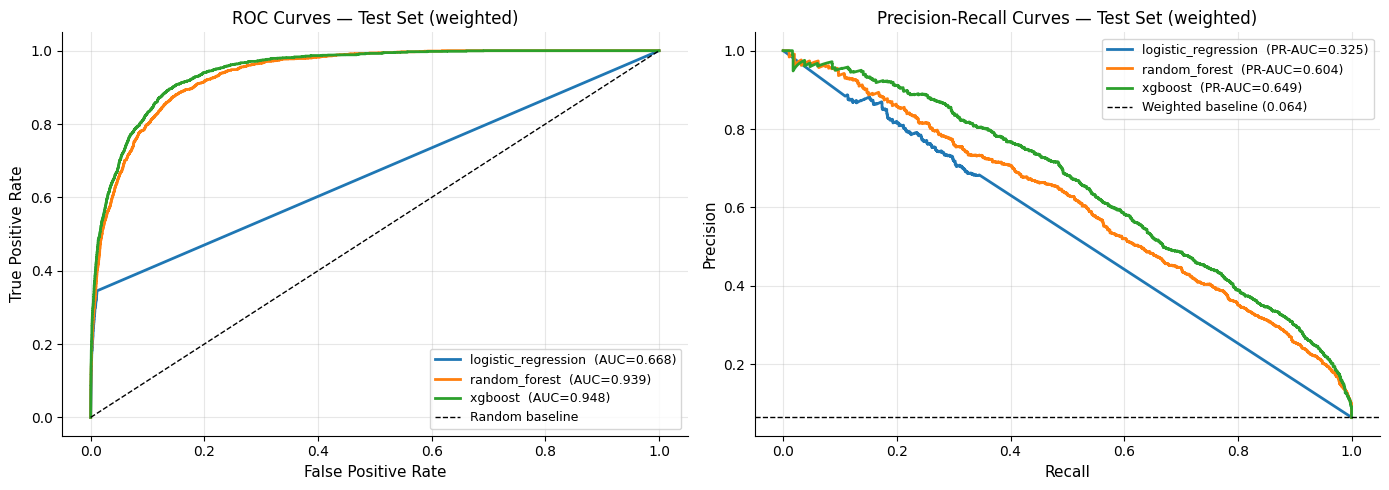

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, average_precision_score

X_test = data['X_test']
y_test = np.asarray(data['y_test'])
w_test = np.asarray(data['w_test'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC curves
for name, model in models.items():
    proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba, sample_weight=w_test)
    auc = roc_auc_score(y_test, proba, sample_weight=w_test)
    axes[0].plot(fpr, tpr, linewidth=2, label=f'{name}  (AUC={auc:.3f})')

axes[0].plot([0,1],[0,1],'k--', linewidth=1, label='Random baseline')
axes[0].set_xlabel('False Positive Rate', fontsize=11)
axes[0].set_ylabel('True Positive Rate', fontsize=11)
axes[0].set_title('ROC Curves — Test Set (weighted)', fontsize=12)
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# PR curves
baseline = np.average(y_test, weights=w_test)
for name, model in models.items():
    proba = model.predict_proba(X_test)[:, 1]
    prec, rec, _ = precision_recall_curve(y_test, proba, sample_weight=w_test)
    pr_auc = average_precision_score(y_test, proba, sample_weight=w_test)
    axes[1].plot(rec, prec, linewidth=2, label=f'{name}  (PR-AUC={pr_auc:.3f})')

axes[1].axhline(y=baseline, color='k', linestyle='--', linewidth=1,
                label=f'Weighted baseline ({baseline:.3f})')
axes[1].set_xlabel('Recall', fontsize=11)
axes[1].set_ylabel('Precision', fontsize=11)
axes[1].set_title('Precision-Recall Curves — Test Set (weighted)', fontsize=12)
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('results/figures/roc_pr_curves_notebook.png', dpi=150, bbox_inches='tight')
plt.show()

3. Threshold Selection — Why 0.5 is Wrong

Default threshold=0.5 is calibrated for balanced classes. With 6.2% positive rate, the model needs a lower threshold to recall enough >50K individuals to be profitable. The optimal threshold is chosen by maximising profit on the validation set.

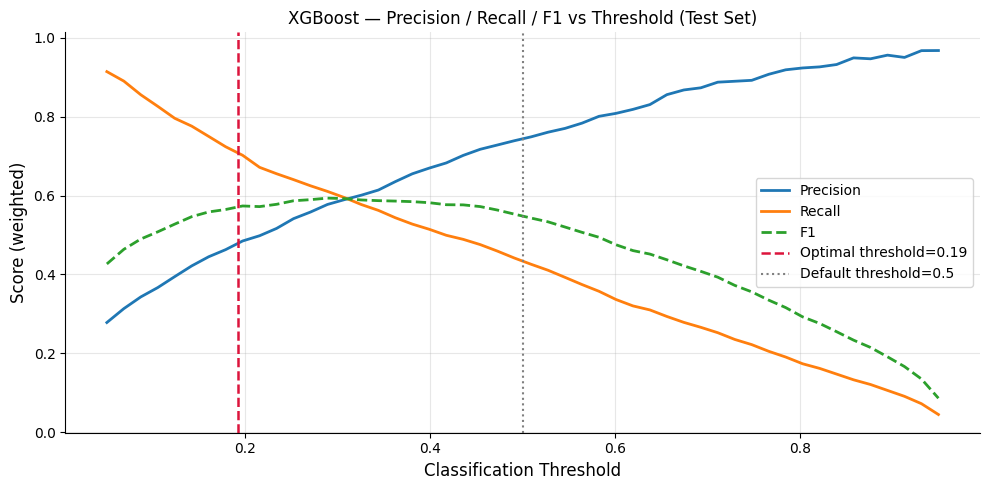

In [ ]:
# Show precision/recall tradeoff across thresholds for XGBoost
from sklearn.metrics import precision_score, recall_score, f1_score

xgb = models['xgboost']
proba_test = xgb.predict_proba(X_test)[:, 1]

thresholds = np.linspace(0.05, 0.95, 50)
precisions, recalls, f1s = [], [], []

for t in thresholds:
    y_pred = (proba_test >= t).astype(int)
    precisions.append(precision_score(y_test, y_pred, sample_weight=w_test, zero_division=0))
    recalls.append(recall_score(y_test, y_pred, sample_weight=w_test, zero_division=0))
    f1s.append(f1_score(y_test, y_pred, sample_weight=w_test, zero_division=0))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, precisions, linewidth=2, label='Precision')
ax.plot(thresholds, recalls,    linewidth=2, label='Recall')
ax.plot(thresholds, f1s,        linewidth=2, label='F1', linestyle='--')
ax.axvline(x=optimal_threshold, color='crimson', linestyle='--',
           linewidth=1.8, label=f'Optimal threshold={optimal_threshold:.2f}')
ax.axvline(x=0.5, color='grey', linestyle=':', linewidth=1.5, label='Default threshold=0.5')
ax.set_xlabel('Classification Threshold', fontsize=12)
ax.set_ylabel('Score (weighted)', fontsize=12)
ax.set_title('XGBoost — Precision / Recall / F1 vs Threshold (Test Set)', fontsize=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('results/figures/threshold_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()

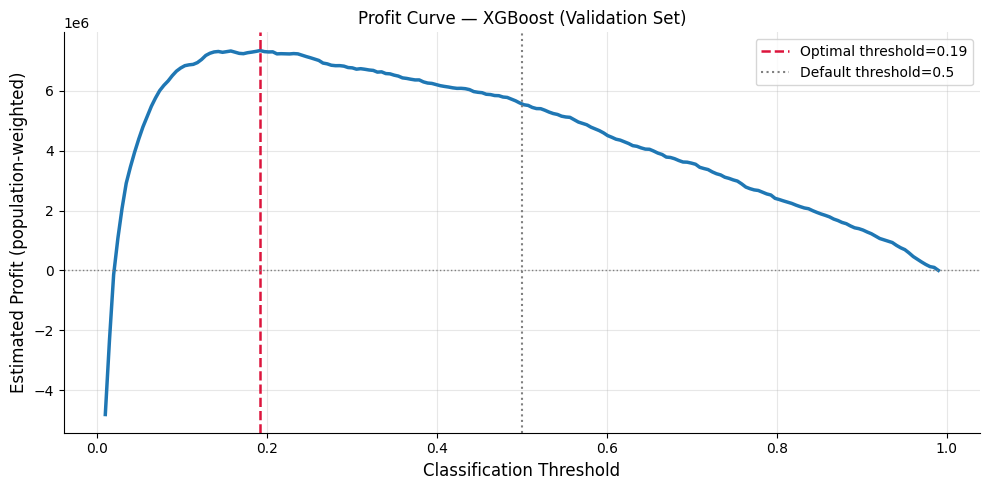

,optimal_threshold,optimal_profit,base_profit_at_05,absolute_gain,contact_cost,revenue,conversion_rate
0,0.1922,7336927.04,5573879.33,1763047.71,1.0,50.0,0.1


In [ ]:
# Show profit curve
profit_df = pd.read_csv('results/tables/profit_curve_val.csv')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(profit_df['threshold'], profit_df['profit'], linewidth=2.5)
ax.axvline(x=optimal_threshold, color='crimson', linestyle='--',
           linewidth=1.8, label=f'Optimal threshold={optimal_threshold:.2f}')
ax.axvline(x=0.5, color='grey', linestyle=':', linewidth=1.5, label='Default threshold=0.5')
ax.axhline(y=0, color='grey', linestyle=':', linewidth=1)
ax.set_xlabel('Classification Threshold', fontsize=12)
ax.set_ylabel('Estimated Profit (population-weighted)', fontsize=12)
ax.set_title('Profit Curve — XGBoost (Validation Set)', fontsize=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('results/figures/profit_curve_notebook.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary
summary = pd.read_csv('results/tables/optimal_threshold.csv')
display(summary)

4. Confusion Matrices at Optimal Threshold

Comparing XGBoost at default threshold=0.5 vs optimal threshold=0.1774. Values are population-weighted counts.

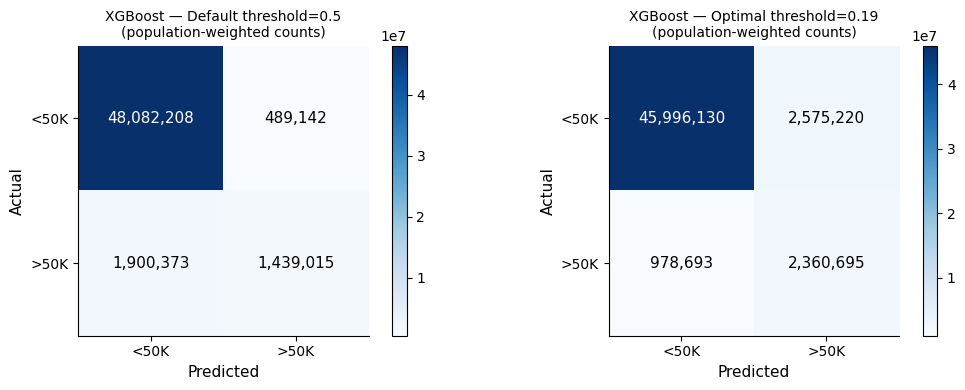

In [ ]:
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, thresh, title in zip(
    axes,
    [0.5, optimal_threshold],
    ['Default threshold=0.5', f'Optimal threshold={optimal_threshold:.2f}']
):
    y_pred = (proba_test >= thresh).astype(int)
    cm = confusion_matrix(y_test, y_pred, sample_weight=w_test)

    im = ax.imshow(cm, cmap='Blues', interpolation='nearest')
    fig.colorbar(im, ax=ax)
    classes = ['<50K', '>50K']
    ax.set_xticks([0,1]); ax.set_xticklabels(classes)
    ax.set_yticks([0,1]); ax.set_yticklabels(classes)
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('Actual', fontsize=11)
    ax.set_title(f'XGBoost — {title}\n(population-weighted counts)', fontsize=10)

    for i in range(2):
        for j in range(2):
            ax.text(j, i, f'{cm[i,j]:,.0f}', ha='center', va='center',
                    color='white' if cm[i,j] > cm.max()/2 else 'black', fontsize=11)

plt.tight_layout()
plt.savefig('results/figures/confusion_matrices_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

- At threshold=0.5:  recall is low — misses most >50K earners

- At threshold=0.18: better recall — contacts more but catches far more positives

5. Feature Importance — XGBoost

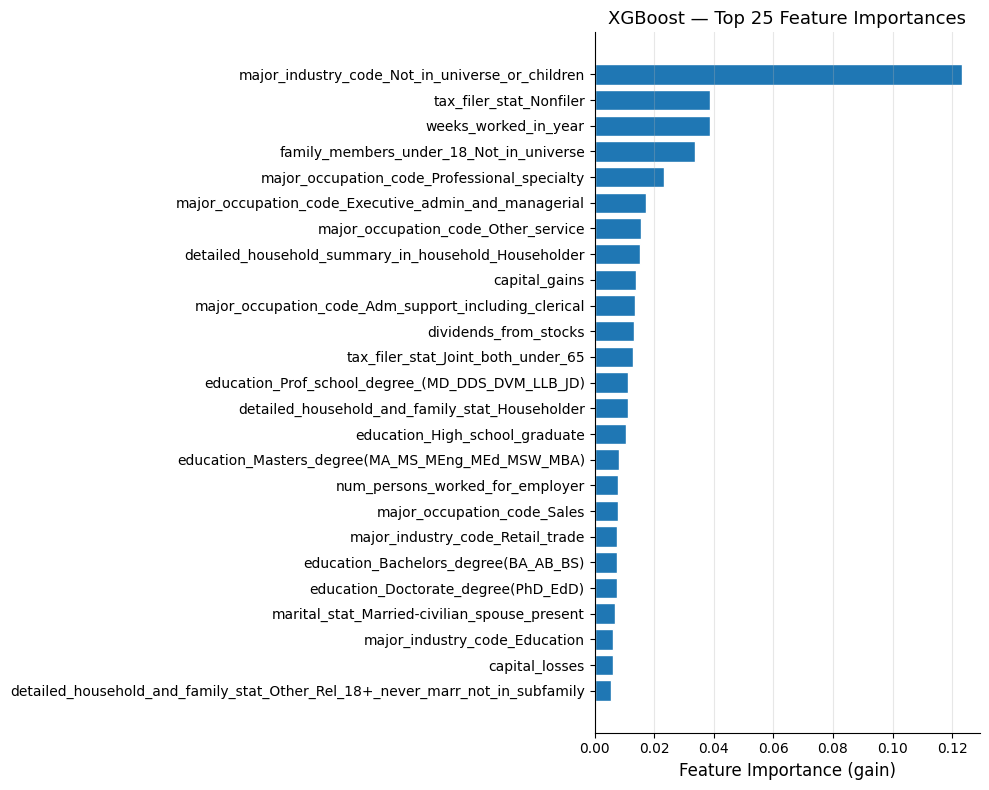

In [ ]:
xgb_model = models['xgboost']
importances = xgb_model.feature_importances_
feature_names = data['X_train'].columns.tolist()

imp_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
imp_df = imp_df.sort_values('importance', ascending=False).head(25)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(imp_df['feature'][::-1], imp_df['importance'][::-1], edgecolor='white')
ax.set_xlabel('Feature Importance (gain)', fontsize=12)
ax.set_title('XGBoost — Top 25 Feature Importances', fontsize=13)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('results/figures/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

**Note on `major_industry_code_Not_in_universe_or_children`:** This dominates at 0.12 gain — it effectively captures people outside the workforce entirely (children, retirees, unemployed). The model leans on this heavily to rule out non-earners before considering anything else. This is worth monitoring, if this feature behaves unexpectedly in production data, predictions will degrade significantly.

6. SHAP Analysis — Model Interpretability

SHAP (SHapley Additive exPlanations) shows the contribution of each feature to individual predictions. This is critical for the client to understand and trust the model.

In [ ]:
import shap

# Sample for speed — SHAP on full test set is slow
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(data['X_test']), size=1000, replace=False)
X_sample = data['X_test'].iloc[sample_idx]

explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_sample)

print(f'SHAP computed on {len(X_sample):,} test samples.')

SHAP computed on 1,000 test samples.


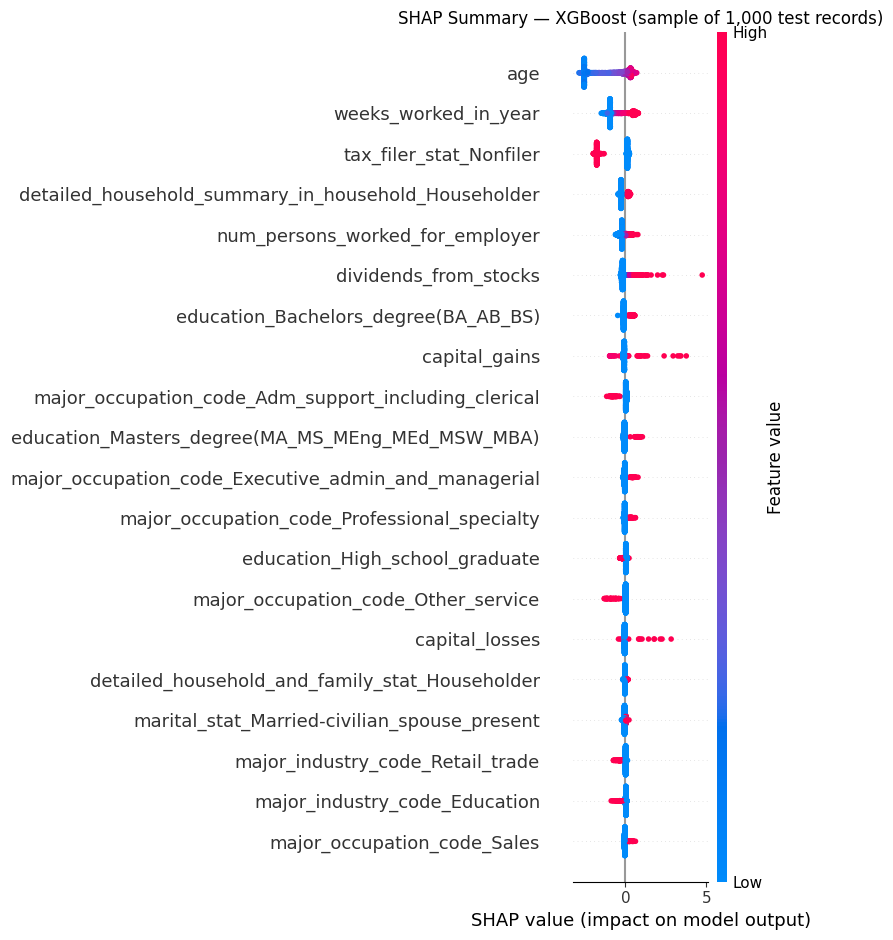

In [ ]:
# SHAP summary plot — beeswarm
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_sample, max_display=20, show=False)
plt.title('SHAP Summary — XGBoost (sample of 1,000 test records)', fontsize=12)
plt.tight_layout()
plt.savefig('results/figures/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

Each dot is one prediction. Position on the x-axis shows whether that feature 
pushed the prediction toward >50K (right) or <50K (left). Colour shows the 
feature value: red is high, blue is low.

Key takeaways:
- **age**: high age (red dots) pushes strongly toward >50K — peak earning years effect
- **weeks_worked_in_year**: more weeks worked (red) → higher income prediction, as expected
- **dividends_from_stocks** and **capital_gains**: even small values (red outliers) 
  push predictions sharply right — investment activity is a strong signal
- **tax_filer_stat_Nonfiler**: being a non-filer (red = yes) pushes strongly toward 
  <50K — makes intuitive sense, non-filers tend to have low or no income

This confirms the model is learning economically sensible patterns, not noise.

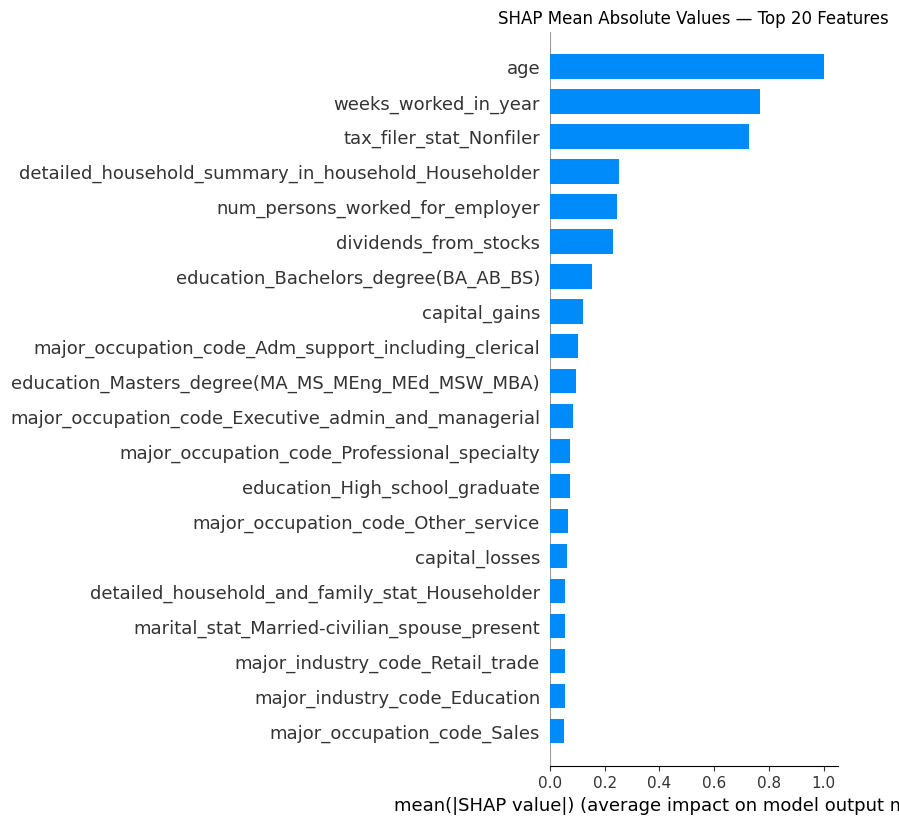


Top 10 features by mean |SHAP|:
age                                                     1.0011
weeks_worked_in_year                                    0.7664
tax_filer_stat_Nonfiler                                 0.7274
detailed_household_summary_in_household_Householder     0.2512
num_persons_worked_for_employer                         0.2454
dividends_from_stocks                                   0.2311
education_Bachelors_degree(BA_AB_BS)                    0.1540
capital_gains                                           0.1228
major_occupation_code_Adm_support_including_clerical    0.1016
education_Masters_degree(MA_MS_MEng_MEd_MSW_MBA)        0.0950
dtype: float32


In [ ]:
# SHAP bar plot — mean absolute SHAP values
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_sample, plot_type='bar', max_display=20, show=False)
plt.title('SHAP Mean Absolute Values — Top 20 Features', fontsize=12)
fig = plt.gcf()
fig.set_size_inches(10, 8)
plt.savefig('results/figures/shap_bar.png', dpi=150, bbox_inches='tight', pad_inches=0.5)
plt.show()

# Top 5 SHAP features
mean_shap = pd.Series(np.abs(shap_values).mean(axis=0),
                      index=X_sample.columns)
print('\nTop 10 features by mean |SHAP|:')
print(mean_shap.sort_values(ascending=False).head(10).round(4))

7. Sensitivity Analysis — Is the Threshold Robust?

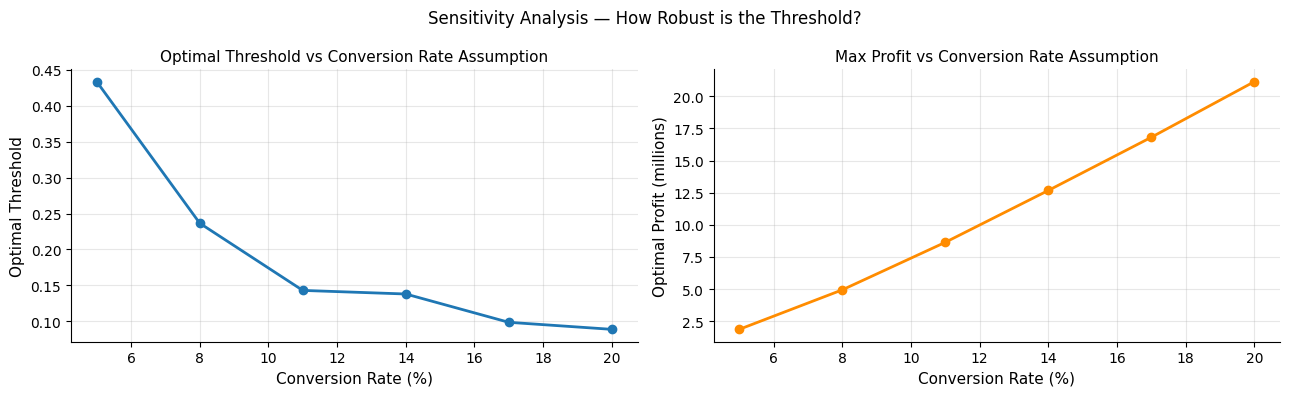

,conversion_rate,optimal_threshold,optimal_profit
0,0.05,0.4335,1868741.73
1,0.08,0.2365,4940492.43
2,0.11,0.1430,8636758.01
3,0.14,0.1380,12671106.39
4,0.17,0.0986,16806159.23
5,0.20,0.0888,21130212.55


In [ ]:
sens_df = pd.read_csv('results/tables/profit_sensitivity.csv')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(sens_df['conversion_rate'] * 100, sens_df['optimal_threshold'],
             'o-', linewidth=2)
axes[0].set_xlabel('Conversion Rate (%)', fontsize=11)
axes[0].set_ylabel('Optimal Threshold', fontsize=11)
axes[0].set_title('Optimal Threshold vs Conversion Rate Assumption', fontsize=11)
axes[0].grid(alpha=0.3)

axes[1].plot(sens_df['conversion_rate'] * 100, sens_df['optimal_profit'] / 1e6,
             'o-', linewidth=2, color='darkorange')
axes[1].set_xlabel('Conversion Rate (%)', fontsize=11)
axes[1].set_ylabel('Optimal Profit (millions)', fontsize=11)
axes[1].set_title('Max Profit vs Conversion Rate Assumption', fontsize=11)
axes[1].grid(alpha=0.3)

plt.suptitle('Sensitivity Analysis — How Robust is the Threshold?', fontsize=12)
plt.tight_layout()
plt.savefig('results/figures/sensitivity_analysis_notebook.png', dpi=150, bbox_inches='tight')
plt.show()

display(sens_df)

**Final Recommendation:**

- Best model: XGBoost

- Operating threshold: 0.1774 (profit-optimised on the validation set)

- Test ROC-AUC: 0.9512

- Test PR-AUC: 0.6673 (vs weighted baseline 0.064)

- Test Brier Score: 0.0340 (well-calibrated probabilities)

- Population contacted: ~9.7% of weighted population (test set) at the optimal threshold

- Why not Random Forest: Too conservative at threshold = 0.5, with low recall, so it misses most >50K earners

- Why not Logistic Regression: Significantly weaker discrimination than XGBoost (lower ROC-AUC)

- Threshold caveat: The optimal threshold will shift if the true conversion rate differs from the assumed 10% used in profit simulation